Visual telemetry often involves displaying data streams in real-time to monitor system performance, sensor readings, or other dynamic metrics. This example demonstrates a basic setup for real-time plotting of simulated data using `matplotlib`'s animation features.

First, let's import the necessary libraries: `matplotlib.pyplot` for plotting and `numpy` for generating simulated data.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import deque
import time
import random
from IPython.display import display, clear_output

Next, we'll set up a function to generate simulated data points. In a real-world scenario, this data would come from sensors, logs, or other telemetry sources. We'll use a `deque` (double-ended queue) to efficiently store a fixed number of recent data points for our real-time plot.

In [ ]:
# Parameters for the simulation
MAX_POINTS = 50 # Number of data points to display at once
UPDATE_INTERVAL_MS = 100 # Update interval in milliseconds

# Initialize data containers
time_data = deque(maxlen=MAX_POINTS)
value_data = deque(maxlen=MAX_POINTS)

def generate_data():
    """Generates a new simulated data point."""
    current_time = time.time()
    # Simulate a sensor reading with some noise
    current_value = np.sin(current_time / 5) * 10 + random.uniform(-2, 2)
    return current_time, current_value

# Populate initial data
for _ in range(MAX_POINTS):
    t, v = generate_data()
    time_data.append(t)
    value_data.append(v)
    time.sleep(0.05) # Simulate some delay

Now, let's create the plotting function. This function will be called repeatedly to update the plot. We'll use `clear_output(wait=True)` to clear the previous plot in Jupyter environments and `display(fig)` to show the updated plot. This creates a simple animation effect.

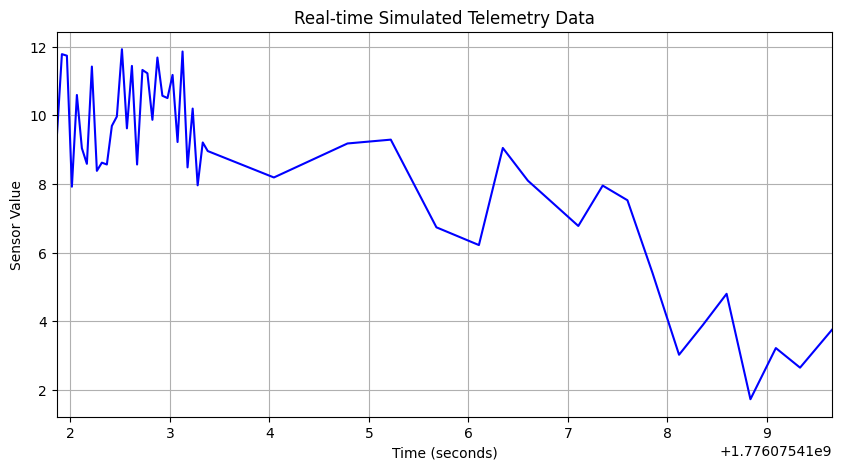

In [ ]:
def update_plot():
    """Generates new data and updates the plot."""
    # Generate new data
    new_time, new_value = generate_data()
    time_data.append(new_time)
    value_data.append(new_value)

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(list(time_data), list(value_data), 'b-')

    # Customize the plot
    ax.set_title('Real-time Simulated Telemetry Data')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Sensor Value')
    ax.grid(True)

    # Adjust x-axis to show only the latest MAX_POINTS time range
    if len(time_data) > 1:
        ax.set_xlim(time_data[0], time_data[-1])

    # Display the plot and clear previous output for animation effect
    clear_output(wait=True)
    display(fig)
    plt.close(fig) # Close the figure to free up memory

# Run the animation for a few seconds
print(f"Displaying real-time telemetry for {MAX_POINTS} updates...")
for i in range(MAX_POINTS):
    update_plot()
    time.sleep(UPDATE_INTERVAL_MS / 1000.0)

print("Telemetry simulation finished.")

### Explanation of Components:

*   **`deque`**: Used to efficiently store a fixed number of data points. When a new point is added, the oldest one is automatically removed, making it ideal for moving window plots.
*   **`generate_data()`**: This function simulates a new sensor reading. In a real application, you would replace this with code that reads from your actual telemetry source (e.g., a serial port, a network socket, a database query).
*   **`update_plot()`**: This is the core function that gets new data, updates the `deque`s, and then redraws the `matplotlib` plot. `clear_output(wait=True)` and `display(fig)` are crucial in Jupyter environments to create an animation effect.
*   **`time.sleep()`**: Controls the update rate of the plot. In a real-time system, this might be driven by event loops or sensor polling intervals.

### Further Enhancements:

*   **More Sophisticated Data Sources**: Connect to actual hardware, APIs, or data streams.
*   **Multiple Plots/Subplots**: Display different telemetry metrics simultaneously.
*   **Interactive Plots**: Use libraries like `Plotly`, `Bokeh`, or `Dash` for more interactive and web-based dashboards.
*   **Error Handling**: Add robust error handling for data acquisition.
*   **Performance Optimization**: For very high data rates, consider more optimized plotting methods or data aggregation.